In [1]:
import re
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load Cleaning Reports for All Subsets

In [2]:
REPORTS = {
    'components': 'dataset/figma-data/cleaned/components/cleaning_report.json',
    'uis_pretty': 'dataset/figma-data/cleaned/uis/pretty/cleaning_report.json',
    'uis_messy':  'dataset/figma-data/cleaned/uis/messy/cleaning_report.json',
}

reports: dict[str, dict] = {}

for subset, path in REPORTS.items():
    p = Path(path)

    if not p.exists():
        print(f'WARNING: Report for "{subset}" not found at {p} -- skipping. '
              f'Run the cleaner notebook for this subset first.')
        continue

    with open(p, 'r', encoding='utf-8') as f:
        reports[subset] = json.load(f)

    n = reports[subset]['summary']['total_files']
    print(f'Loaded "{subset}": {n} files')

if not reports:
    raise FileNotFoundError(
        'No cleaning reports found. Run the cleaner notebook once per subset '
        '(components, uis/pretty, uis/messy) before running this analysis.'
    )

print(f'\nSubsets available for analysis: {list(reports.keys())}')

Loaded "components": 30 files
Loaded "uis_pretty": 5 files
Loaded "uis_messy": 5 files

Subsets available for analysis: ['components', 'uis_pretty', 'uis_messy']


## 2. Combined Long-Form Table per Mockup

Merges the `files` lists of all loaded reports into a single DataFrame and adds the subset (`subset`) as well as the group (`group`) per row -- for `components` this is the complexity level (simple/medium/hard), for the two `uis` subsets it is the structural-quality variant itself.

In [3]:
def extract_group(subset: str, filename: str) -> str:
    """Determines the complexity/variant group of a single file.

    For the 'components' subset, the group (simple/medium/hard) is encoded
    as a path prefix in the filename (e.g. 'simple/1.json'). The 'uis_pretty'
    and 'uis_messy' subsets contain no such prefix -- their group is simply
    the structural-quality variant itself.
    """
    if subset == 'components':
        m = re.match(r'^(simple|medium|hard)[/\\]', filename)
        return m.group(1) if m else 'unknown'

    return subset.removeprefix('uis_')  # 'pretty' | 'messy'


frames = []

for subset, report in reports.items():
    sub_df = pd.DataFrame(report['files'])
    sub_df['subset'] = subset
    sub_df['group'] = sub_df['filename'].apply(lambda fn: extract_group(subset, fn))
    sub_df['file_label'] = subset + '/' + sub_df['filename'].str.replace('\\', '/', regex=False)

    frames.append(sub_df)

df = pd.concat(frames, ignore_index=True)

print(f'Combined dataset: {len(df)} files across {df["subset"].nunique()} subsets')
df.head(3)

Combined dataset: 40 files across 3 subsets


,filename,size_before,size_after,reduction_percent,attributes_before,attributes_after,name,subset,group,file_label
0,hard\1.json,134385,17777,86.77,5503,800,1 [Bearbeitungs-Dialog],components,hard,components/hard/1.json
1,hard\10.json,257405,47994,81.35,11181,2280,10 [Admin-Panel-Liste],components,hard,components/hard/10.json
2,hard\2.json,168533,27358,83.77,7182,1365,2 [Nutzer-Tabelle],components,hard,components/hard/2.json


## 3. Summary per Subset

Mirrors the same structure as the table *"Reduction achieved by cleaning, grouped by test dataset subset"* in Chapter 4: one row per subset (Components, of which Simple/Medium/Hard, UIs Pretty/Messy) plus a total row across all files. In addition to the unweighted mean of the per-file reduction, a size-weighted reduction (sum of size after / sum of size before) is reported as well, since it is more informative across files of very different sizes.

In [4]:
def summarize(sub_df: pd.DataFrame, label: str) -> dict:
    size_before = sub_df['size_before'].sum()
    size_after = sub_df['size_after'].sum()
    weighted_reduction = 100 * (1 - size_after / size_before) if size_before else 0

    return {
        'Subset': label,
        'Files': len(sub_df),
        'Avg. Reduction (%)': round(sub_df['reduction_percent'].mean(), 2),
        'Weighted Reduction (%)': round(weighted_reduction, 2),
        'Avg. Attributes Before': round(sub_df['attributes_before'].mean(), 1),
        'Avg. Attributes After': round(sub_df['attributes_after'].mean(), 1),
    }


rows = []

if 'components' in reports:
    comp_df = df[df['subset'] == 'components']
    rows.append(summarize(comp_df, 'Components'))

    for level, label in [
        ('simple', '  of which Simple'),
        ('medium', '  of which Medium'),
        ('hard',   '  of which Hard'),
    ]:
        level_df = comp_df[comp_df['group'] == level]
        if len(level_df):
            rows.append(summarize(level_df, label))

if 'uis_pretty' in reports:
    rows.append(summarize(df[df['subset'] == 'uis_pretty'], 'UIs (Pretty)'))

if 'uis_messy' in reports:
    rows.append(summarize(df[df['subset'] == 'uis_messy'], 'UIs (Messy)'))

rows.append(summarize(df, 'Total'))

summary_df = pd.DataFrame(rows)
summary_df

,Subset,Files,Avg. Reduction (%),Weighted Reduction (%),Avg. Attributes Before,Avg. Attributes After
0,Components,30,86.54,85.89,4561.5,722.8
1,of which Simple,10,86.21,85.28,1793.4,308.4
2,of which Medium,10,87.63,87.46,3705.1,528.2
3,of which Hard,10,85.78,85.29,8186.0,1331.8
4,UIs (Pretty),5,82.33,81.78,19245.8,3741.0
5,UIs (Messy),5,83.51,83.07,12294.4,2638.0
6,Total,40,85.63,84.02,7363.6,1339.5


### Export as CSV

Saves both the summary table and the combined per-mockup long-form table so both can be reused directly for the tables in Chapter 4 or for further analysis.

In [5]:
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary_csv_path = RESULTS_DIR / 'cleaning_summary_by_subset.csv'
summary_df.to_csv(summary_csv_path, index=False)

detail_csv_path = RESULTS_DIR / 'cleaning_by_mockup.csv'
df.to_csv(detail_csv_path, index=False)

print(f'Summary saved to: {summary_csv_path}')
print(f'Per-mockup detail saved to: {detail_csv_path}')

Summary saved to: results\cleaning_summary_by_subset.csv
Per-mockup detail saved to: results\cleaning_by_mockup.csv


## 4. Visualizations

### Reduction per File (All Subsets)

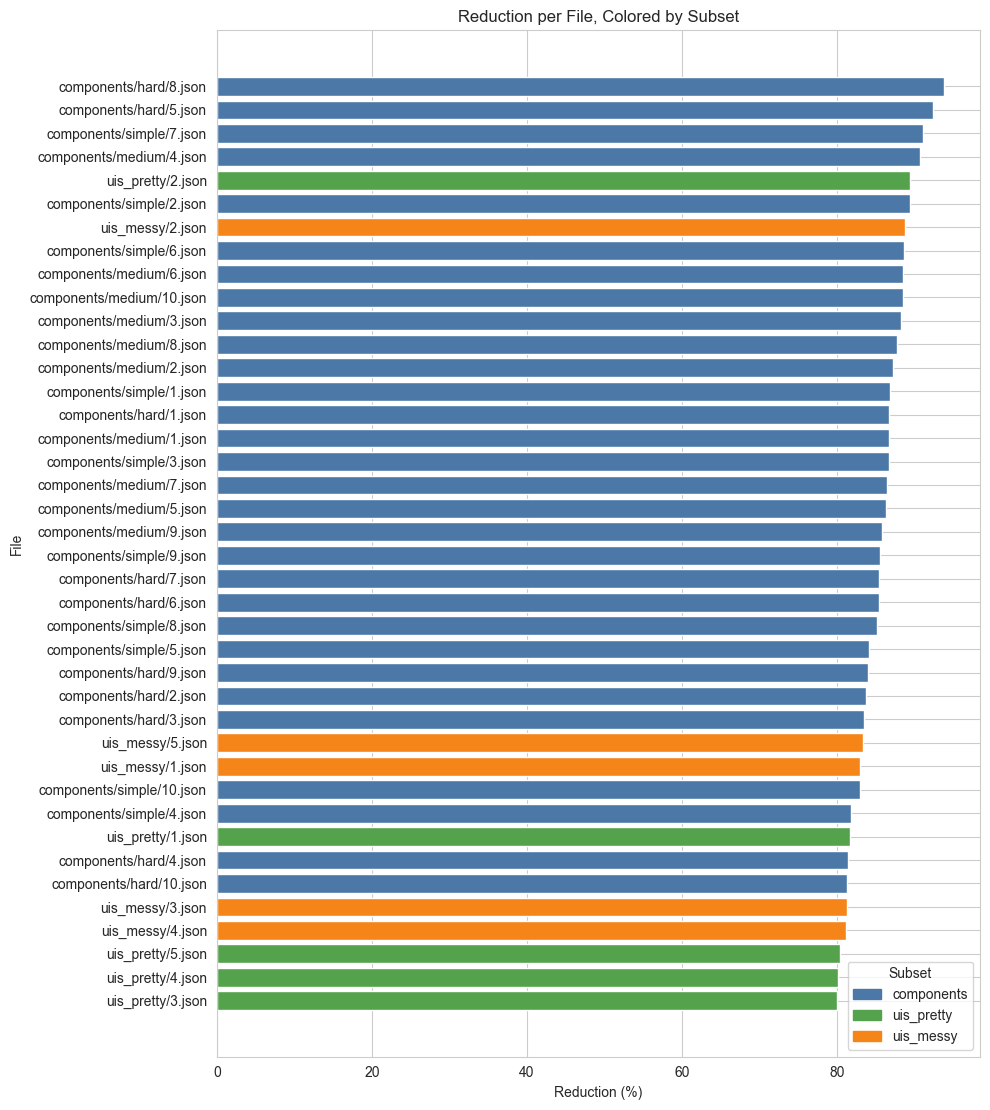

In [6]:
plot_df = df.sort_values('reduction_percent', ascending=True)

SUBSET_COLORS = {
    'components': '#4C78A8',
    'uis_pretty': '#54A24B',
    'uis_messy':  '#F58518',
}
colors = plot_df['subset'].map(SUBSET_COLORS).fillna('#999999')

plt.figure(figsize=(10, max(6, 0.28 * len(plot_df))))
plt.barh(plot_df['file_label'], plot_df['reduction_percent'], color=colors)
plt.xlabel('Reduction (%)')
plt.ylabel('File')
plt.title('Reduction per File, Colored by Subset')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SUBSET_COLORS.values()]
plt.legend(handles, SUBSET_COLORS.keys(), title='Subset', loc='lower right')

plt.tight_layout()
plt.show()

### Average Reduction per Group and Subset

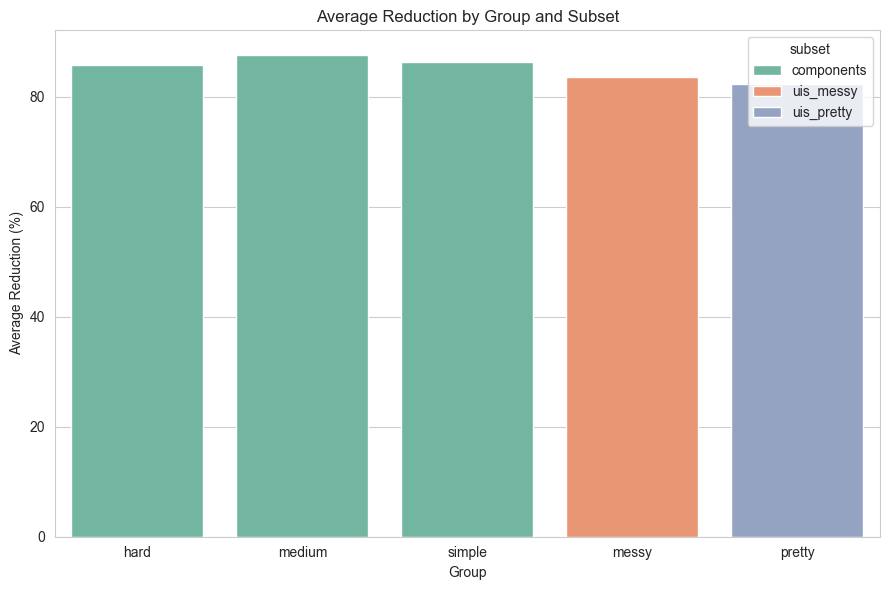

In [7]:
group_summary = df.groupby(['subset', 'group'])['reduction_percent'].mean().reset_index()

plt.figure(figsize=(9, 6))
sns.barplot(x='group', y='reduction_percent', hue='subset', data=group_summary, palette='Set2')
plt.xlabel('Group')
plt.ylabel('Average Reduction (%)')
plt.title('Average Reduction by Group and Subset')
plt.tight_layout()
plt.show()

### Distribution of Reduction by Subset

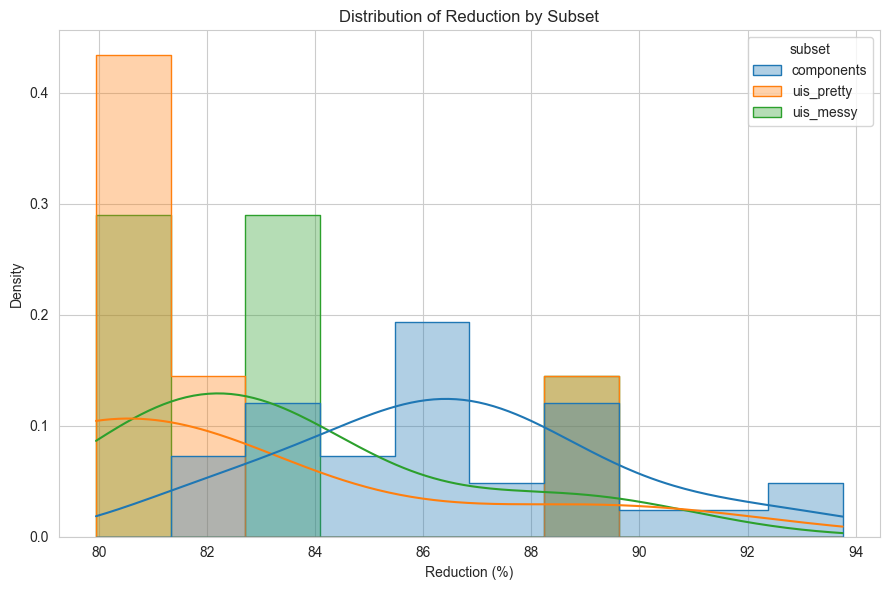

In [8]:
plt.figure(figsize=(9, 6))
sns.histplot(
    data=df,
    x='reduction_percent',
    hue='subset',
    bins=10,
    kde=True,
    stat='density',
    common_norm=False,
    element='step',
    alpha=0.35,
)
plt.xlabel('Reduction (%)')
plt.ylabel('Density')
plt.title('Distribution of Reduction by Subset')
plt.tight_layout()
plt.show()

### Attributes Before and After Cleaning per Subset

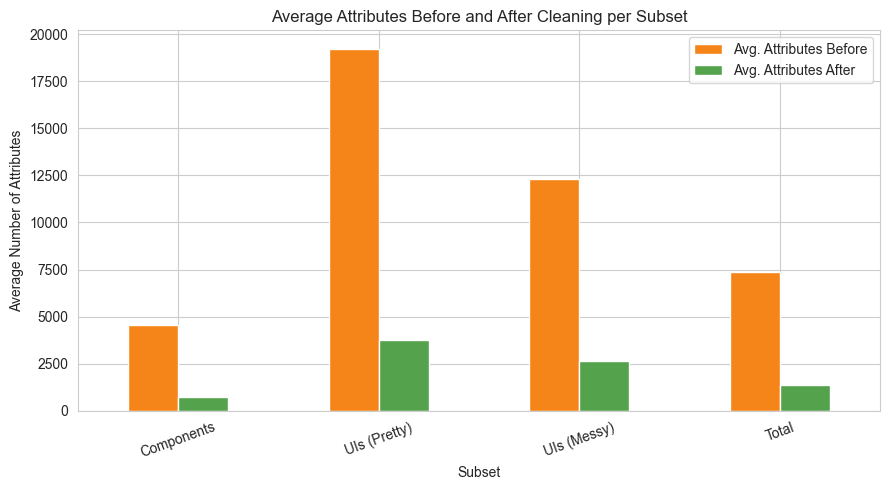

In [9]:
top_level = summary_df[~summary_df['Subset'].str.startswith(' ')]

ax = top_level.plot(
    x='Subset',
    y=['Avg. Attributes Before', 'Avg. Attributes After'],
    kind='bar',
    figsize=(9, 5),
    rot=20,
    color=['#F58518', '#54A24B'],
)
ax.set_title('Average Attributes Before and After Cleaning per Subset')
ax.set_xlabel('Subset')
ax.set_ylabel('Average Number of Attributes')
plt.tight_layout()
plt.show()